# Montgomery County Crime – Cleaning & Exploratory Analysis

**Goal:** turn the raw Montgomery County (MD) open-data crime extract into an analysis-ready table with a **reusable cleaning pipeline**, then answer two questions:

1. **Where** are the high-density crime hotspots?
2. **When** do incidents peak (hour of day, day of week, by crime type)?

Source: [Montgomery County Open Data – Crime (icn6-v9z3)](https://data.montgomerycountymd.gov/Public-Safety/Crime/icn6-v9z3). Each row is one offence reported to Montgomery County Police and partner agencies, classified under NIBRS.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from crime_pipeline import CleaningPipeline, CORE_STEPS, load_raw
from crime_pipeline import analysis as A

pd.set_option("display.max_columns", 30)
RAW = ROOT / "data" / "raw" / "Crime.csv"

## 1. Raw data: what are we working with?

In [2]:
raw = load_raw(RAW)          # only the needed columns, read as strings via the pyarrow engine
print(f"{len(raw):,} rows × {raw.shape[1]} columns")
raw.head(3)

510,898 rows × 20 columns


,Incident ID,Offence Code,Dispatch Date / Time,Start_Date_Time,End_Date_Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,Zip Code,Agency,Place,Sector,Beat,Latitude,Longitude
0,201194204,2305,06/25/2018 07:03:12 PM,06/22/2018 06:00:00 PM,06/22/2018 08:00:00 PM,23F,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,MONTGOMERY VILLAGE,19200 BLK WATKINS MILL RD,MONTGOMERY VILLAGE,20886,MCPD,Parking Lot - Commercial,R,6R2,39.17057,-77.2089
1,201192754,3562,06/15/2018 09:28:52 AM,06/15/2018 09:28:00 AM,06/15/2018 09:28:00 AM,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,WHEATON,17000 BLK BATCHELLORS FOREST RD,OLNEY,20832,MCPD,School/College - DO NOT USE,J,4J2,39.1358,-77.0453
2,201197266,5404,07/15/2018 10:14:12 PM,07/15/2018 10:14:00 PM,07/15/2018 11:45:00 PM,90D,1,Crime Against Society,Driving Under the Influence,DRIVING UNDER THE INFLUENCE LIQUOR,WHEATON,<NA>,SILVER SPRING,20906,MCPD,Street - In vehicle,K,4K2,39.06421,-77.069


In [3]:
# Data-quality snapshot of the raw extract
quality = pd.DataFrame({
    "missing_%": raw.isna().mean().mul(100).round(1),
    "distinct": raw.nunique(),
}).sort_values("missing_%", ascending=False)
quality.head(12)

,missing_%,distinct
End_Date_Time,55.6,158746
Dispatch Date / Time,14.4,400235
Block Address,7.8,23510
Zip Code,0.7,206
Police District Name,0.3,8
Start_Date_Time,0.0,374682
Incident ID,0.0,470248
Offence Code,0.0,360
Crime Name1,0.0,4
Victims,0.0,10


In [4]:
# A few of the problems the pipeline has to handle
print("City spellings for Silver Spring:", sorted(raw["City"].dropna().str.upper().str.strip()
      .loc[lambda s: s.str.contains("SILVER")].unique())[:10])
lat = pd.to_numeric(raw["Latitude"], errors="coerce")
print("Rows with latitude == 0 or missing:", int(((lat == 0) | lat.isna()).sum()))

City spellings for Silver Spring: ['SILVER', 'SILVER  SPRING', 'SILVER APRING', 'SILVER SPING', 'SILVER SPIRNG', 'SILVER SPRIG', 'SILVER SPRIGN', 'SILVER SPRIING', 'SILVER SPRIN', 'SILVER SPRIN G']
Rows with latitude == 0 or missing: 25106


## 2. The reusable cleaning pipeline

Each step is a small, tested function `df -> df` (see `src/crime_pipeline/cleaning.py`). The `CleaningPipeline` runs them in order and logs rows in/out, time taken, and a note per step. To clean a new extract, re-run the same pipeline; to change behaviour, edit `config.py` or add a step.

In [5]:
pipe = CleaningPipeline(CORE_STEPS)
df = pipe.run(raw)
pipe.report_frame()

,step,rows_in,rows_out,seconds,note,rows_removed
0,standardize_columns,510898,510898,0.006702,kept 20 cols,0
1,drop_exact_duplicates,510898,510898,0.492921,0 exact duplicates,0
2,parse_datetimes,510898,510898,3.049708,0 unparseable start dates,0
3,drop_missing_start,510898,510898,0.003029,0 rows without start date,0
4,fix_time_order,510898,510898,0.014243,"8,456 start/end swapped",0
5,clean_text_fields,510898,510898,1.852922,10 text cols normalised,0
6,standardize_cities,510898,510898,0.101590,"293 distinct -> 46 cities; 170 variants fixed,...",0
7,flag_non_crimes,510898,510898,0.050325,"6,213 non-crime records flagged",0
8,clean_zip_codes,510898,510898,0.170202,19 invalid ZIPs nulled,0
9,validate_coordinates,510898,510898,0.285529,"25,106 rows with invalid/missing coords",0


In [6]:
print(f"{len(raw):,} raw rows -> {len(df):,} clean rows in {pipe.total_seconds():.1f}s")
print(f"Date range: {df.start_datetime.min():%Y-%m-%d} to {df.start_datetime.max():%Y-%m-%d}")
print(f"Geocoded (valid coords): {df.has_valid_coords.mean():.1%}")
print(f"Start time recorded as exactly 00:00 or 12:00 ('time unknown' defaults): {df.time_placeholder.mean():.1%}")

510,898 raw rows -> 510,898 clean rows in 7.6s
Date range: 2016-07-01 to 2026-10-06
Geocoded (valid coords): 95.1%
Start time recorded as exactly 00:00 or 12:00 ('time unknown' defaults): 8.1%


### Benchmark: ad-hoc notebook cleaning vs. the pipeline
`scripts/benchmark.py` times a typical one-off notebook approach (read every column with type inference, row-wise `.apply()` fixes) against the pipeline on the same file, and against re-loading the cached Parquet output.

In [7]:
bench_file = ROOT / "reports" / "benchmark.json"
pd.Series(json.loads(bench_file.read_text())) if bench_file.exists() else "run: python scripts/benchmark.py data/raw/Crime.csv"

rows_raw                    510898.00
rows_clean_baseline         510898.00
rows_clean_pipeline         510898.00
baseline_seconds                69.95
pipeline_seconds                 8.57
cached_reload_seconds            0.12
time_saved_pct_first_run        87.80
time_saved_pct_cached           99.80
memory_mb_baseline             249.80
memory_mb_pipeline              83.00
repeats                          3.00
dtype: float64

## 3. When do incidents happen?

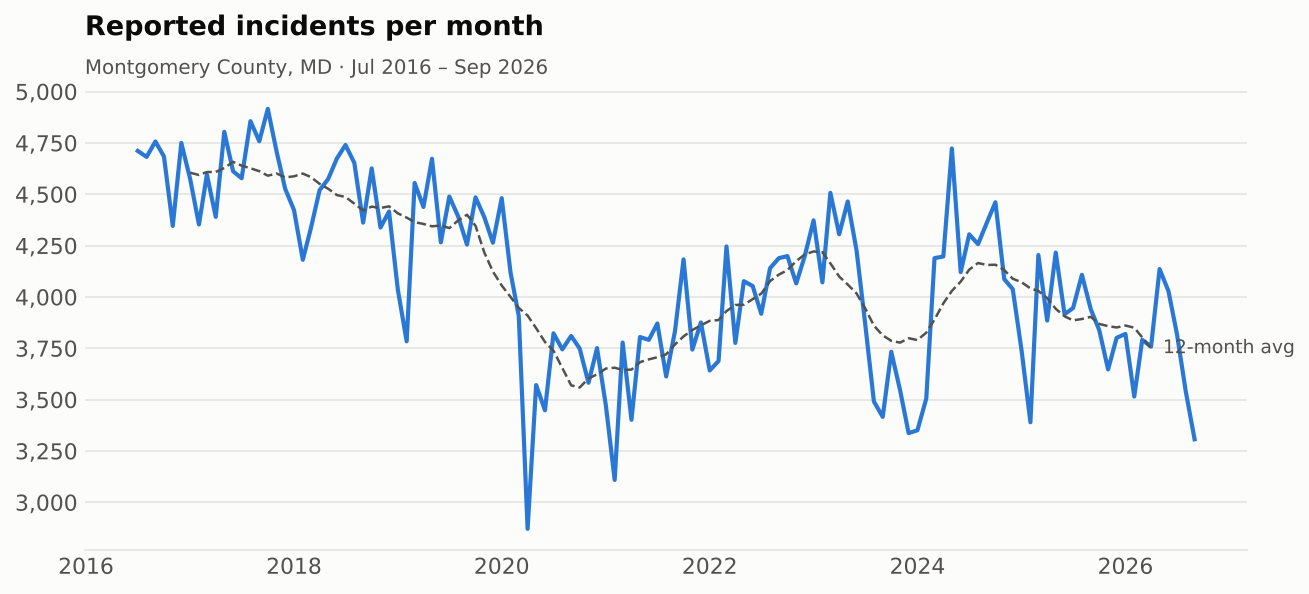

In [8]:
display(Image(ROOT / "reports/figures/01_monthly_trend.png"))

In [9]:
A.peak_hours(df, n=5).assign(share=lambda t: (t.share * 100).round(2))

,incidents,share
hour,,
17,30430,6.48
15,30058,6.40
18,29887,6.36
16,29392,6.26
19,27896,5.94


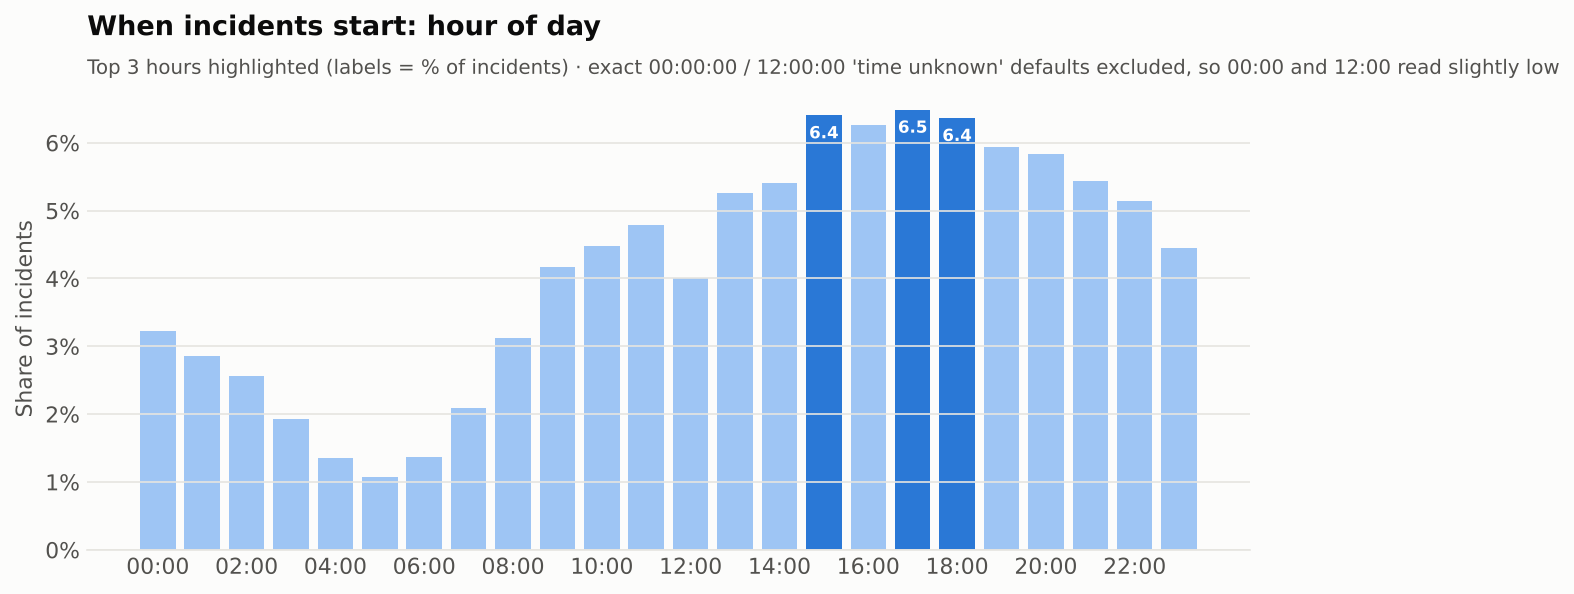

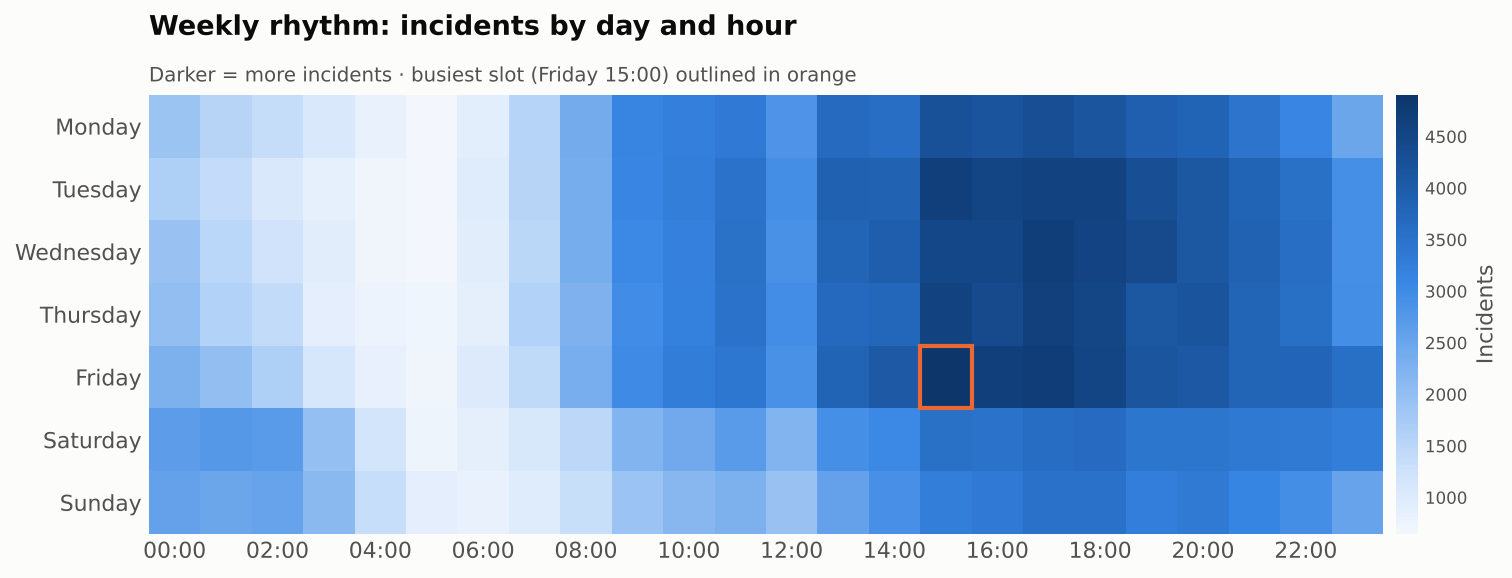

In [10]:
display(Image(ROOT / "reports/figures/02_hour_of_day.png"))
display(Image(ROOT / "reports/figures/03_day_hour_heatmap.png"))

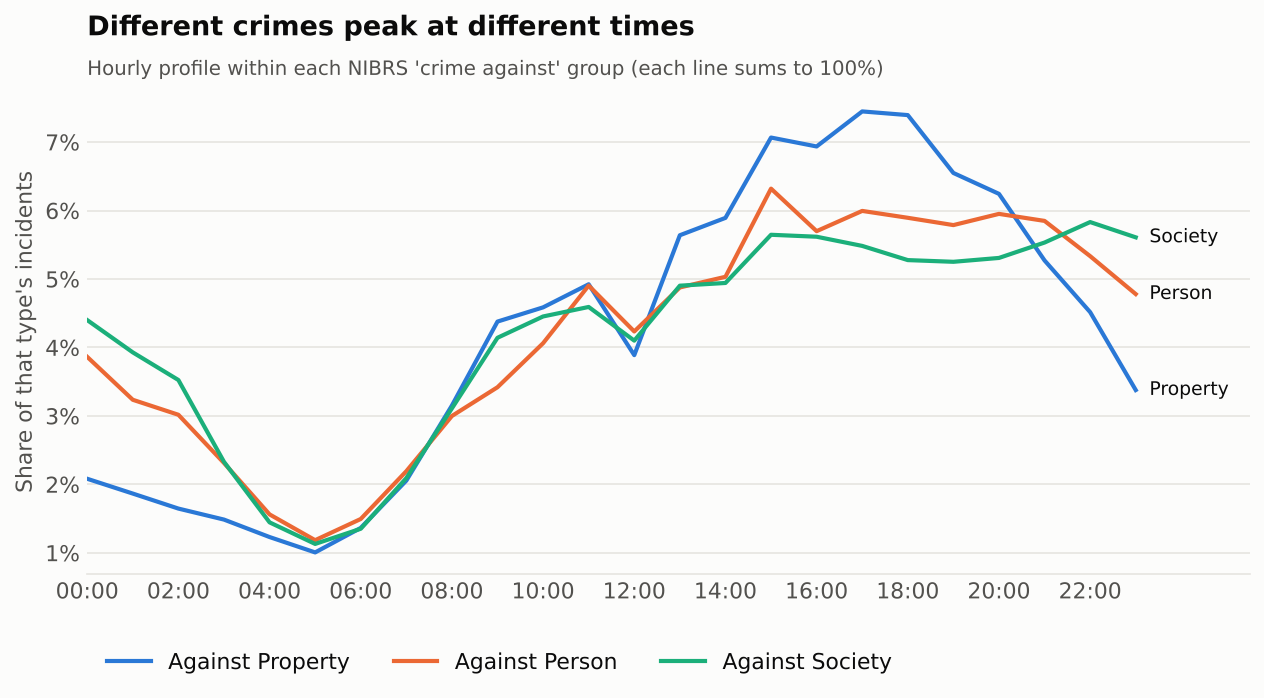

In [11]:
display(Image(ROOT / "reports/figures/06_hour_by_crime_type.png"))

**Note on 00:00 records.** Many reports carry a start time of exactly `00:00:00` when the true time is unknown (e.g. a theft discovered next morning). Counting them would create a fake "midnight peak", so the time-of-day analysis excludes them (`time_placeholder` flag).

## 4. Where are the hotspots?

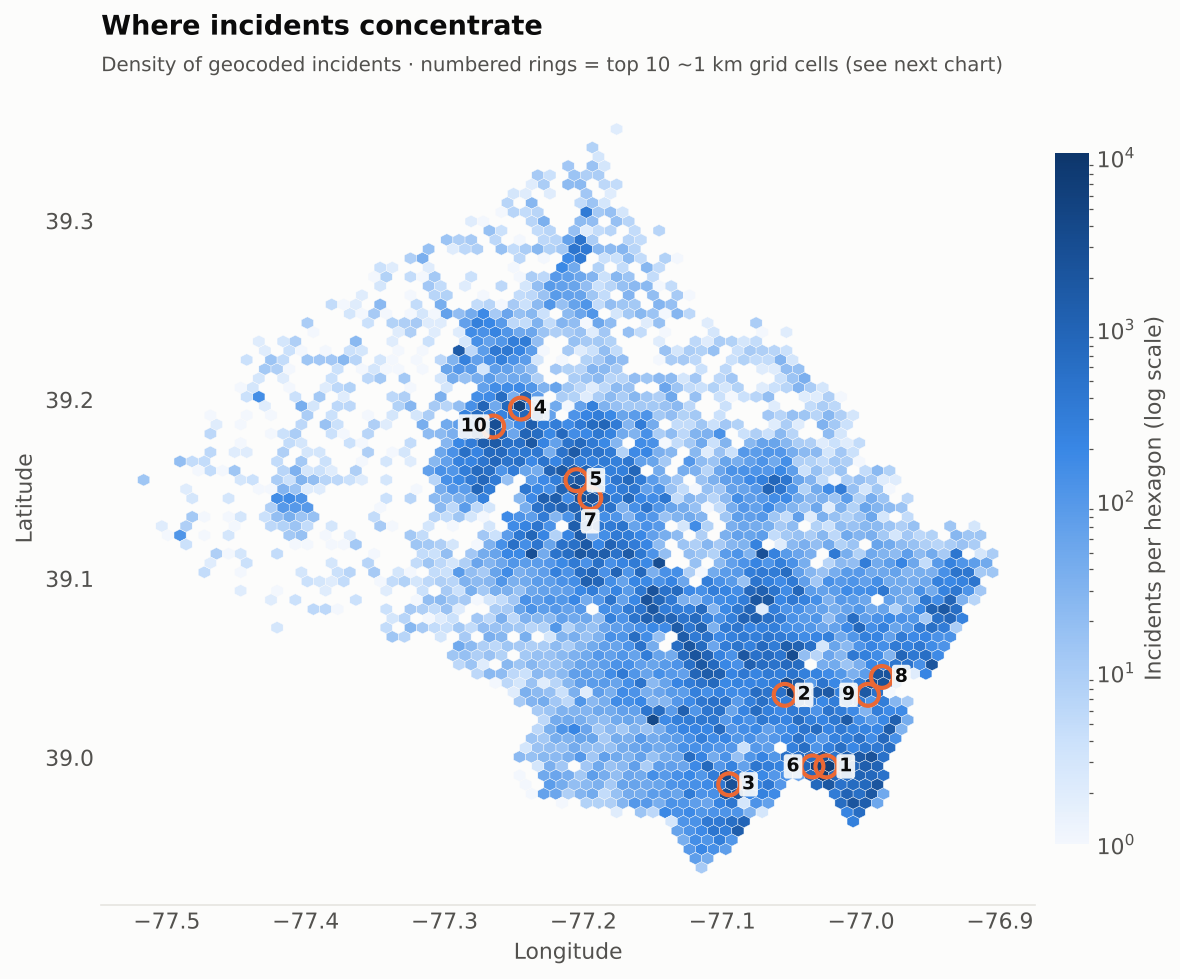

In [12]:
display(Image(ROOT / "reports/figures/04_hotspot_density_map.png"))

In [13]:
hot = A.hotspot_cells(df, top=10)
hot.assign(share_of_county=lambda t: (t.share_of_county * 100).round(2),
           cumulative_share=lambda t: (t.cumulative_share * 100).round(1))

,incidents,lat,lon,share_of_county,cumulative_share,city,top_block,top_category
grid_id,,,,,,,,
"38.995,-77.025",18871,38.994999,-77.025002,3.88,3.9,SILVER SPRING,8100 BLK GEORGIA AVE,All Other Offenses
"39.035,-77.055",10500,39.035000,-77.055000,2.16,6.0,SILVER SPRING,11100 BLK VEIRS MILL RD,Shoplifting
"38.985,-77.095",6378,38.985001,-77.095001,1.31,7.4,BETHESDA,4800 BLK BETHESDA AVE,All Other Offenses
"39.195,-77.245",6226,39.195000,-77.245003,1.28,8.6,GERMANTOWN,20900 BLK FREDERICK RD,Shoplifting
"39.155,-77.205",6167,39.154999,-77.205002,1.27,9.9,GAITHERSBURG,700 BLK RUSSELL AVE,Shoplifting
"38.995,-77.035",4823,38.994999,-77.035004,0.99,10.9,SILVER SPRING,8400 BLK COLESVILLE RD,All Other Offenses
"39.145,-77.195",4692,39.145000,-77.195000,0.97,11.9,GAITHERSBURG,300 BLK N SUMMIT AVE,All Other Offenses
"39.045,-76.985",4662,39.044998,-76.985001,0.96,12.8,SILVER SPRING,11400 BLK LOCKWOOD DR,All Other Offenses
"39.185,-77.265",4544,39.185001,-77.264999,0.94,13.8,GERMANTOWN,20000 BLK AIRCRAFT DR,All Other Offenses


Top 5% of occupied ~1 km cells hold 44% of geocoded incidents


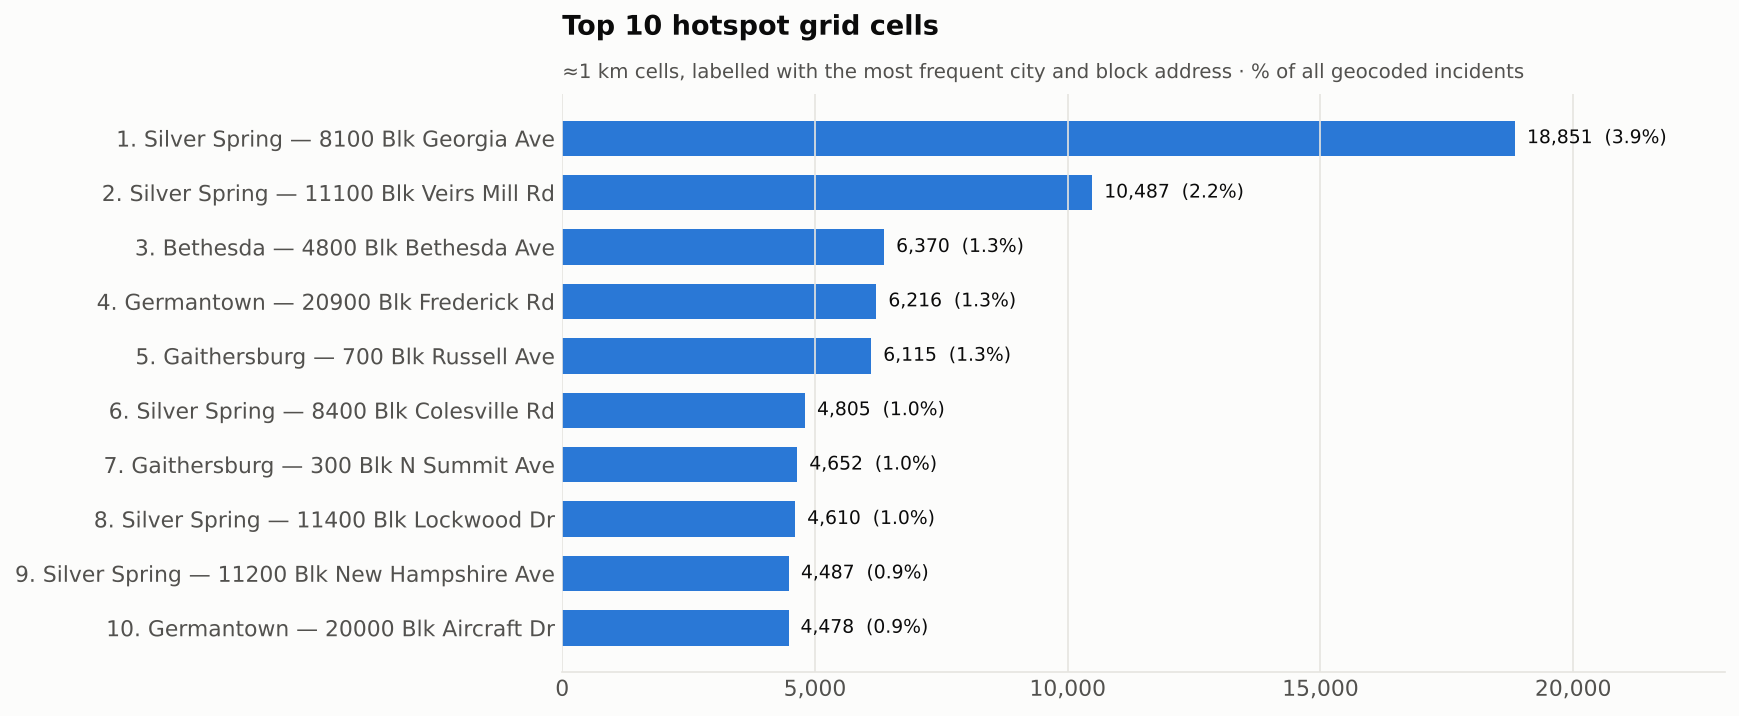

In [14]:
print(f"Top 5% of occupied ~1 km cells hold {A.concentration(df, 0.05):.0%} of geocoded incidents")
display(Image(ROOT / "reports/figures/05_top_hotspots.png"))

In [15]:
A.district_summary(df)

,incidents,crimes_against_person_pct,share_pct
district,,,
SILVER SPRING,106953,10.3,21.0
WHEATON,94294,10.6,18.5
MONTGOMERY VILLAGE,85741,12.8,16.8
BETHESDA,73100,7.8,14.4
ROCKVILLE,69907,9.0,13.7
GERMANTOWN,64307,13.1,12.6
TAKOMA PARK,15033,7.5,3.0
OTHER,15,20.0,0.0


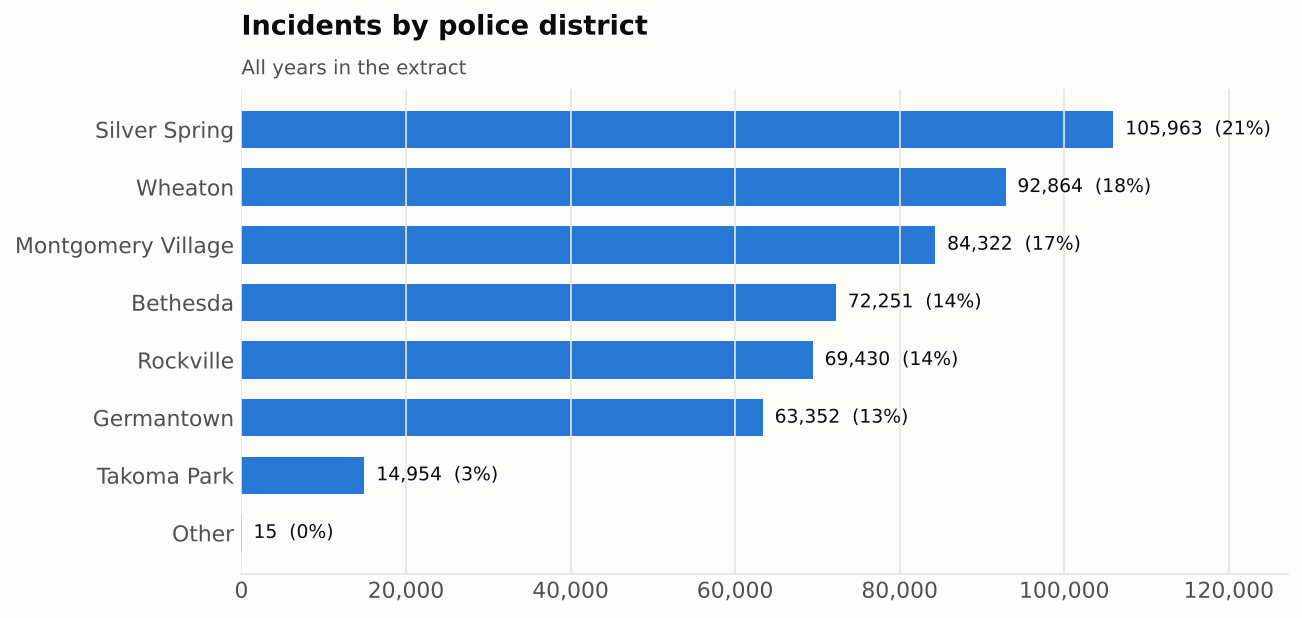

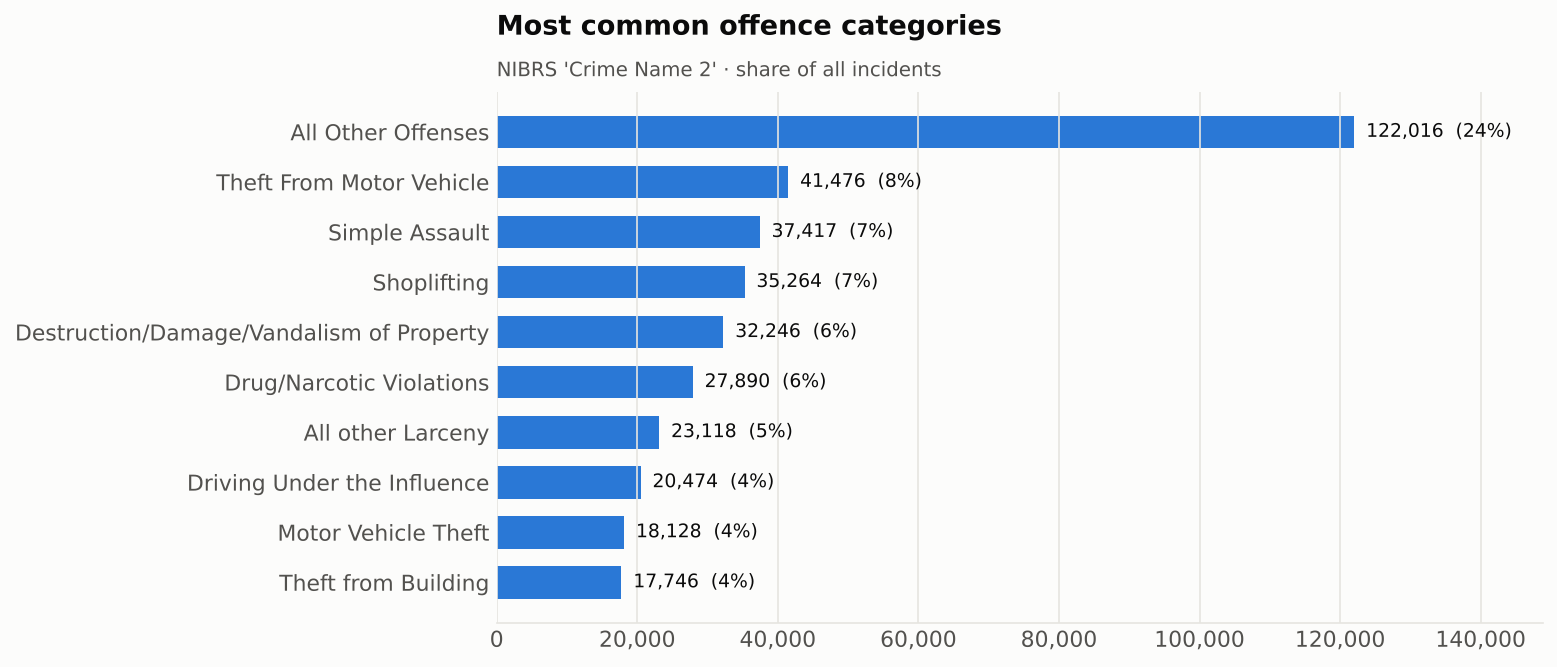

In [16]:
display(Image(ROOT / "reports/figures/07_police_districts.png"))
display(Image(ROOT / "reports/figures/08_top_categories.png"))

An interactive version of the hotspot map (zoomable heat-map with the top-10 cells marked) is saved as `reports/hotspot_map.html` – download and open it in a browser.

## 5. Key findings

In [17]:
findings = json.loads((ROOT / "reports" / "findings.json").read_text())
{k: findings[k] for k in ["peak_hours", "quietest_hour", "busiest_day_hour", "busiest_day",
                          "top5pct_cells_share_pct", "top10_cells_share_pct", "peak_hour_by_type"]}

{'peak_hours': [{'hour': '17:00', 'share_pct': 6.49},
  {'hour': '15:00', 'share_pct': 6.4},
  {'hour': '18:00', 'share_pct': 6.36}],
 'quietest_hour': '05:00',
 'busiest_day_hour': 'Friday 15:00',
 'busiest_day': 'Friday',
 'top5pct_cells_share_pct': 44.6,
 'top10_cells_share_pct': 14.8,
 'peak_hour_by_type': {'Crime Against Property': '17:00',
  'Crime Against Person': '15:00',
  'Crime Against Society': '22:00'}}

See the README for the written summary of findings and the limitations of this data (reported crime only, geocoding gaps, unknown start times, NIBRS reclassifications).